<a href="https://colab.research.google.com/github/Mrzrm77/Combined-BERT-with-RNN-and-LSTM/blob/main/Combine_BERT_with_LSTM_and_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Download Dataset

In [ ]:
!sudo apt-get install git-archive-all
!git clone --depth 1 \
  --filter=blob:none \
  --sparse https://github.com/IndoNLP/indonlu.git

%cd indonlu
!git sparse-checkout set dataset/smsa_doc-sentiment-prosa


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package git-archive-all
Cloning into 'indonlu'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 22 (delta 1), reused 16 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 6.22 KiB | 2.07 MiB/s, done.
Resolving deltas: 100% (1/1), done.
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 12 (delta 0), reused 5 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 17.14 KiB | 5.71 MiB/s, done.
/content/indonlu
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 6 (delta 0), reused 6 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), 973.71 KiB | 3

In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import re


# Load Dataset

In [ ]:
DATA_PATH = "/content/indonlu/dataset/smsa_doc-sentiment-prosa/"

train_df = pd.read_csv(DATA_PATH + "train_preprocess.tsv", sep="\t")
valid_df = pd.read_csv(DATA_PATH + "valid_preprocess.tsv", sep="\t")
test_df  = pd.read_csv(DATA_PATH + "test_preprocess.tsv", sep="\t")

# EDA

Dataframes reloaded with 'text' and 'label' columns.

First 5 rows of train_df after correction:
                                                text     label
0  warung ini dimiliki oleh pengusaha pabrik tahu...  positive
1  mohon ulama lurus dan k212 mmbri hujjah partai...   neutral
2  lokasi strategis di jalan sumatera bandung . t...  positive
3  betapa bahagia nya diri ini saat unboxing pake...  positive
4  duh . jadi mahasiswa jangan sombong dong . kas...  negative


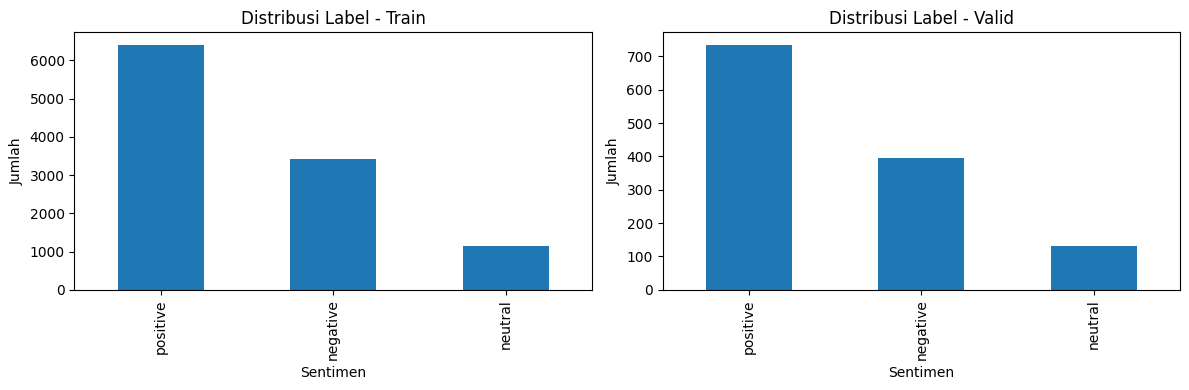

In [ ]:
# Reload dataframes with proper headers
train_df = pd.read_csv(DATA_PATH + "train_preprocess.tsv", sep="\t", header=None)
train_df.columns = ["text", "label"]

valid_df = pd.read_csv(DATA_PATH + "valid_preprocess.tsv", sep="\t", header=None)
valid_df.columns = ["text", "label"]

test_df = pd.read_csv(DATA_PATH + "test_preprocess.tsv", sep="\t", header=None)
test_df.columns = ["text", "label"]

print("Dataframes reloaded with 'text' and 'label' columns.")
print("\nFirst 5 rows of train_df after correction:")
print(train_df.head())

# Visualize the distribution of labels
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12,4))

train_df["label"].value_counts().plot(kind="bar", ax=ax[0])
ax[0].set_title("Distribusi Label - Train")
ax[0].set_xlabel("Sentimen")
ax[0].set_ylabel("Jumlah")

valid_df["label"].value_counts().plot(kind="bar", ax=ax[1])
ax[1].set_title("Distribusi Label - Valid")
ax[1].set_xlabel("Sentimen")
ax[1].set_ylabel("Jumlah")

plt.tight_layout()
plt.show()

In [ ]:
print("Label distribution in train_df:")
print(train_df["label"].value_counts())
print(len(train_df))
print("\nLabel distribution in valid_df:")
print(valid_df["label"].value_counts())
print(len(valid_df))
print("\nLabel distribution in test_df:")
print(test_df["label"].value_counts())
print(len(test_df))

Label distribution in train_df:
label
positive    6416
negative    3436
neutral     1148
Name: count, dtype: int64
11000

Label distribution in valid_df:
label
positive    735
negative    394
neutral     131
Name: count, dtype: int64
1260

Label distribution in test_df:
label
positive    208
negative    204
neutral      88
Name: count, dtype: int64
500


# Preprocess Dataset

Cleaning Data

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


In [ ]:
train_df["clean_text"] = train_df["text"].apply(clean_text)
valid_df["clean_text"] = valid_df["text"].apply(clean_text)
test_df["clean_text"]  = test_df["text"].apply(clean_text)


encoding label

In [ ]:
label_map = {"negative": 0, "neutral": 1, "positive": 2}

train_df["label_encoded"] = train_df["label"].map(label_map)
valid_df["label_encoded"] = valid_df["label"].map(label_map)
test_df["label_encoded"] = test_df["label"].map(label_map)

print("Label distribution in train_df after encoding:")
print(train_df["label_encoded"].value_counts())


Label distribution in train_df after encoding:
label_encoded
2    6416
0    3436
1    1148
Name: count, dtype: int64


In [ ]:
print("First 5 rows of train_df with preprocessed text and encoded labels:")
print(train_df[["text", "clean_text", "label", "label_encoded"]].head())

First 5 rows of train_df with preprocessed text and encoded labels:
                                                text  \
0  warung ini dimiliki oleh pengusaha pabrik tahu...   
1  mohon ulama lurus dan k212 mmbri hujjah partai...   
2  lokasi strategis di jalan sumatera bandung . t...   
3  betapa bahagia nya diri ini saat unboxing pake...   
4  duh . jadi mahasiswa jangan sombong dong . kas...   

                                          clean_text     label  label_encoded  
0  warung ini dimiliki oleh pengusaha pabrik tahu...  positive              2  
1  mohon ulama lurus dan k212 mmbri hujjah partai...   neutral              1  
2  lokasi strategis di jalan sumatera bandung tem...  positive              2  
3  betapa bahagia nya diri ini saat unboxing pake...  positive              2  
4  duh jadi mahasiswa jangan sombong dong kasih k...  negative              0  


Random Oversampling

In [ ]:
from imblearn.over_sampling import RandomOverSampler

# Separate features (X) and target (y)
X = train_df[['clean_text']]
y = train_df['label_encoded']

# Initialize RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Resample the training data
X_resampled, y_resampled = ros.fit_resample(X, y)

# Create a new DataFrame with the oversampled data
train_df_oversampled = pd.DataFrame(X_resampled, columns=['clean_text'])
train_df_oversampled['label_encoded'] = y_resampled

print("Original label distribution in train_df:")
print(train_df['label_encoded'].value_counts())

print("\nNew label distribution after oversampling in train_df_oversampled:")
print(train_df_oversampled['label_encoded'].value_counts())

print(f"\nTotal samples after oversampling: {len(train_df_oversampled)}")

Original label distribution in train_df:
label_encoded
2    6416
0    3436
1    1148
Name: count, dtype: int64

New label distribution after oversampling in train_df_oversampled:
label_encoded
2    6416
1    6416
0    6416
Name: count, dtype: int64

Total samples after oversampling: 19248


In [ ]:
train_df = train_df_oversampled[['clean_text', 'label_encoded']]
print("First 5 rows of train_df after selecting 'clean_text' and 'label_encoded' columns:")
print(train_df.head())

First 5 rows of train_df after selecting 'clean_text' and 'label_encoded' columns:
                                          clean_text  label_encoded
0  warung ini dimiliki oleh pengusaha pabrik tahu...              2
1  mohon ulama lurus dan k212 mmbri hujjah partai...              1
2  lokasi strategis di jalan sumatera bandung tem...              2
3  betapa bahagia nya diri ini saat unboxing pake...              2
4  duh jadi mahasiswa jangan sombong dong kasih k...              0


Tokenizer Menggunakan Bert

In [ ]:
from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

def tokenize_batch(text_list, max_len=128):
    return tokenizer(
        text_list,
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors="pt"
    )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

In [ ]:
train_enc = tokenize_batch(train_df["clean_text"].tolist())
valid_enc = tokenize_batch(valid_df["clean_text"].tolist())
test_enc  = tokenize_batch(test_df["clean_text"].tolist())

train_labels = torch.tensor(train_df["label_encoded"].tolist())
valid_labels = torch.tensor(valid_df["label_encoded"].tolist())
test_labels  = torch.tensor(test_df["label_encoded"].tolist())

Buat data loader

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    train_enc["input_ids"],
    train_enc["attention_mask"],
    train_labels
)

valid_dataset = TensorDataset(
    valid_enc["input_ids"],
    valid_enc["attention_mask"],
    valid_labels
)

test_dataset = TensorDataset(
    test_enc["input_ids"],
    test_enc["attention_mask"],
    test_labels
)

In [ ]:
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

train_loader

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Model

In [ ]:
# ============================================
# MODEL INDOBERT + RNN
# ============================================
import torch
import torch.nn as nn
from transformers import BertModel

class IndoBertRNN(nn.Module):
    def __init__(self, hidden_size=128, num_labels=3, freeze_bert=False):
        super(IndoBertRNN, self).__init__()

        # Load IndoBERT
        self.bert = BertModel.from_pretrained("indobenchmark/indobert-base-p1")

        # Freeze IndoBERT (optional)
        if freeze_bert:
            for param in self.bert.parameters():
                param.requires_grad = False

        # RNN layer
        self.rnn = nn.RNN(
            input_size=768,      # hidden size IndoBERT
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=False
        )

        # Fully connected layer
        self.fc = nn.Linear(hidden_size, num_labels)

        # Dropout
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask):
        # BERT output
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        sequence_output = outputs.last_hidden_state    # shape: (batch, seq_len, 768)

        # RNN output
        rnn_out, _ = self.rnn(sequence_output)         # shape: (batch, seq_len, hidden)

        # Ambil hidden state terakhir
        final_hidden = rnn_out[:, -1, :]               # last timestep

        # Fully connected
        logits = self.fc(self.dropout(final_hidden))

        return logits


In [ ]:
# ============================================
# INDOBERT + LSTM (SINGLE DIRECTION)
# ============================================
import torch
import torch.nn as nn
from transformers import BertModel

class IndoBertLSTM(nn.Module):
    def __init__(self, hidden_size=128, num_labels=3, freeze_bert=False):
        super(IndoBertLSTM, self).__init__()

        self.bert = BertModel.from_pretrained("indobenchmark/indobert-base-p1")

        # Optional freeze IndoBERT
        if freeze_bert:
            for p in self.bert.parameters():
                p.requires_grad = False

        self.lstm = nn.LSTM(
            input_size=768,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=False   #LSTM biasa
        )

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        sequence_output = outputs.last_hidden_state  # (batch, seq, 768)

        lstm_out, (h_n, c_n) = self.lstm(sequence_output)

        # Hanya ambil hidden state terakhir LSTM
        final_hidden = h_n[-1, :, :]   # shape: (batch, hidden_size)

        logits = self.fc(self.dropout(final_hidden))

        return logits


In [ ]:
# ============================================
# INDOBERT BASELINE MODEL (Tanpa RNN / LSTM)
# ============================================
import torch
import torch.nn as nn
from transformers import BertModel

class IndoBertBaseline(nn.Module):
    def __init__(self, num_labels=3, freeze_bert=False):
        super(IndoBertBaseline, self).__init__()

        # Load IndoBERT
        self.bert = BertModel.from_pretrained("indobenchmark/indobert-base-p1")

        # Freeze BERT jika diperlukan
        if freeze_bert:
            for param in self.bert.parameters():
                param.requires_grad = False

        # Fully connected layer untuk klasifikasi
        self.fc = nn.Linear(768, num_labels)

        # Dropout
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Ambil representasi [CLS] → pooled_output tersedia tapi lebih stabil menggunakan CLS embedding
        cls_token = outputs.last_hidden_state[:, 0, :]   # shape: (batch, 768)

        logits = self.fc(self.dropout(cls_token))

        return logits


In [ ]:
from tqdm import tqdm


In [ ]:
# ============================================
# TRAIN & VALIDATION FUNCTION (With Progress Bar)
# ============================================
def train_model(model, train_loader, valid_loader, epochs=3, lr=2e-5):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "valid_acc": []
    }

    for epoch in range(epochs):
        print(f"\n====================================")
        print(f"EPOCH {epoch+1}/{epochs}")
        print("====================================")

        # TRAINING
        model.train()
        total_loss = 0

        progress_bar = tqdm(train_loader, desc=f"Training Epoch {epoch+1}")

        for batch in progress_bar:
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            labels = batch[2].to(device)

            optimizer.zero_grad()

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            progress_bar.set_postfix({"batch_loss": loss.item()})

        avg_loss = total_loss / len(train_loader)
        history["train_loss"].append(avg_loss)

        print(f"Average Training Loss: {avg_loss:.4f}")

        # ========================================
        # VALIDATION
        # ========================================
        model.eval()
        total_correct = 0
        total_data = 0

        with torch.no_grad():
            for batch in tqdm(valid_loader, desc="Validating"):
                logits = model(batch[0].to(device), batch[1].to(device))
                preds = torch.argmax(logits, dim=1)

                labels = batch[2].to(device)
                total_correct += (preds == labels).sum().item()
                total_data += labels.size(0)

        val_acc = total_correct / total_data
        history["valid_acc"].append(val_acc)

        print(f"Validation Accuracy: {val_acc:.4f}")

    print("\nTraining Selesai!")

    return history


In [ ]:
# ============================================
# TRAIN MODEL RNN
# ============================================
model_rnn = IndoBertRNN(hidden_size=128, num_labels=3, freeze_bert=False)
history_rnn = train_model(model_rnn, train_loader, valid_loader)

In [ ]:
# ============================================
# TRAIN MODEL LSTM (Single Direction)
# ============================================
model_lstm = IndoBertLSTM(hidden_size=128, num_labels=3, freeze_bert=False)
history_lstm = train_model(model_lstm, train_loader, valid_loader)



EPOCH 1/3


Training Epoch 1: 100%|██████████| 1203/1203 [06:25<00:00,  3.12it/s, batch_loss=0.0973]


Average Training Loss: 0.2156


Validating: 100%|██████████| 79/79 [00:06<00:00, 12.33it/s]


Validation Accuracy: 0.9238

EPOCH 2/3


...

Validation Accuracy: 0.9325

EPOCH 3/3


Training Epoch 3: 100%|██████████| 1203/1203 [06:25<00:00,  3.12it/s, batch_loss=0.0264]


Average Training Loss: 0.0580


Validating: 100%|██████████| 79/79 [00:06<00:00, 12.38it/s]

Validation Accuracy: 0.9397

Training Selesai!


In [ ]:
model_bert = IndoBertBaseline(num_labels=3).to(device)
history_bert = train_model(model_bert, train_loader, valid_loader)


EPOCH 1/3


Training Epoch 1: 100%|██████████| 1203/1203 [06:05<00:00,  3.29it/s, batch_loss=0.514]


Average Training Loss: 0.1733


Validating: 100%|██████████| 79/79 [00:06<00:00, 12.33it/s]


Validation Accuracy: 0.9246

EPOCH 2/3


...

Validation Accuracy: 0.9198

EPOCH 3/3


Training Epoch 3: 100%|██████████| 1203/1203 [06:05<00:00,  3.30it/s, batch_loss=0.00235]


Average Training Loss: 0.0301


Validating: 100%|██████████| 79/79 [00:06<00:00, 12.33it/s]

Validation Accuracy: 0.9278

Training Selesai!


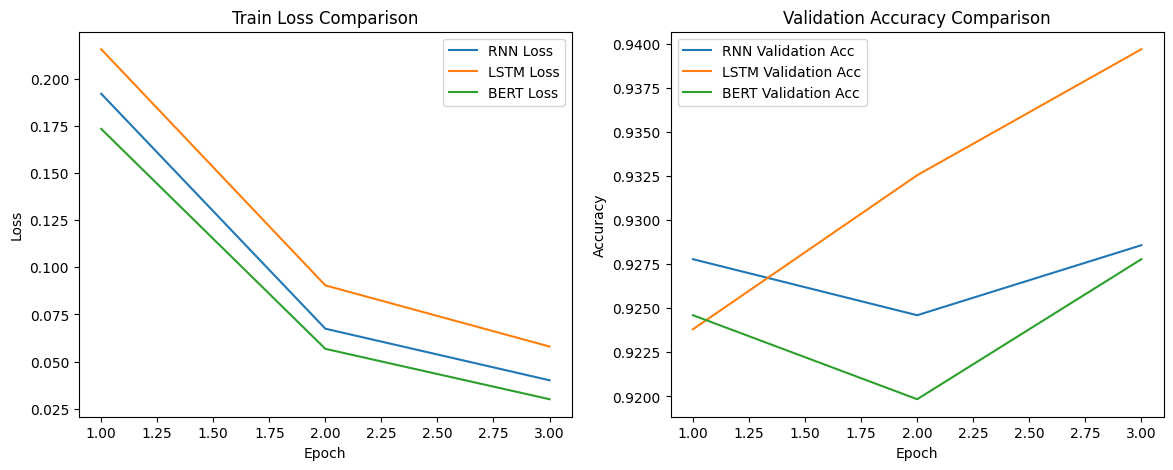

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history_rnn["train_loss"]) + 1)

plt.figure(figsize=(14,5))

# TRAIN LOSS
plt.subplot(1, 2, 1)
plt.plot(epochs, history_rnn["train_loss"], label="RNN Loss")
plt.plot(epochs, history_lstm["train_loss"], label="LSTM Loss")
plt.plot(epochs, history_bert["train_loss"], label="BERT Loss")
plt.title("Train Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# VALID ACC
plt.subplot(1, 2, 2)
plt.plot(epochs, history_rnn["valid_acc"], label="RNN Validation Acc")
plt.plot(epochs, history_lstm["valid_acc"], label="LSTM Validation Acc")
plt.plot(epochs, history_bert["valid_acc"], label="BERT Validation Acc")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


# Evaluate

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            labels = batch[2].to(device)

            logits = model(input_ids, attention_mask)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)


In [ ]:
pred_rnn, true_rnn = evaluate_model(model_rnn, test_loader)

print("===== Classification Report: RNN =====")
print(classification_report(true_rnn, pred_rnn, target_names=["negative", "neutral", "positive"]))


===== Classification Report: RNN =====
              precision    recall  f1-score   support

    negative       0.88      0.97      0.92       204
     neutral       0.84      0.73      0.78        88
    positive       0.92      0.88      0.90       208

    accuracy                           0.89       500
   macro avg       0.88      0.86      0.87       500
weighted avg       0.89      0.89      0.89       500



In [ ]:
pred_lstm, true_lstm = evaluate_model(model_lstm, test_loader)

print("===== Classification Report: LSTM =====")
print(classification_report(true_lstm, pred_lstm, target_names=["negative", "neutral", "positive"]))


===== Classification Report: LSTM =====
              precision    recall  f1-score   support

    negative       0.93      0.98      0.95       204
     neutral       0.93      0.75      0.83        88
    positive       0.92      0.95      0.94       208

    accuracy                           0.93       500
   macro avg       0.93      0.89      0.91       500
weighted avg       0.93      0.93      0.92       500



In [ ]:
pred_bert, true_bert = evaluate_model(model_bert, test_loader)

print(classification_report(true_bert, pred_bert,
                            target_names=["negative", "neutral", "positive"]))


              precision    recall  f1-score   support

    negative       0.86      1.00      0.92       204
     neutral       0.89      0.66      0.76        88
    positive       0.94      0.91      0.93       208

    accuracy                           0.90       500
   macro avg       0.90      0.85      0.87       500
weighted avg       0.90      0.90      0.90       500



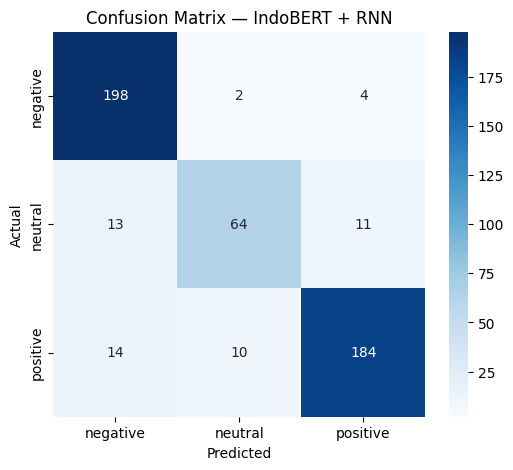

In [ ]:
cm_rnn = confusion_matrix(true_rnn, pred_rnn)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rnn, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negative", "neutral", "positive"],
            yticklabels=["negative", "neutral", "positive"])
plt.title("Confusion Matrix — IndoBERT + RNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


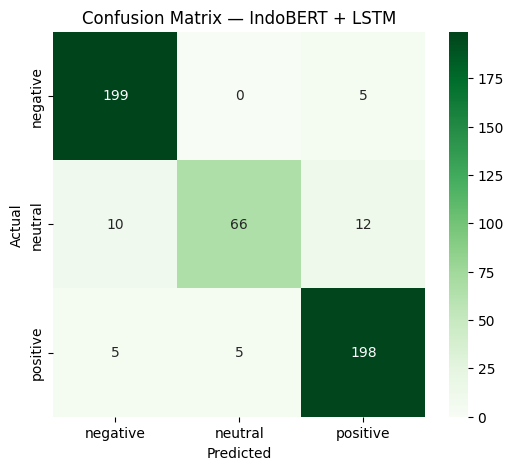

In [ ]:
cm_lstm = confusion_matrix(true_lstm, pred_lstm)

plt.figure(figsize=(6,5))
sns.heatmap(cm_lstm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["negative", "neutral", "positive"],
            yticklabels=["negative", "neutral", "positive"])
plt.title("Confusion Matrix — IndoBERT + LSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


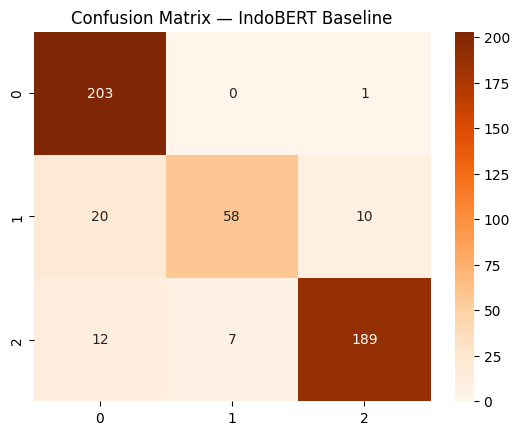

In [ ]:
cm_bert = confusion_matrix(true_bert, pred_bert)
sns.heatmap(cm_bert, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix — IndoBERT Baseline")
plt.show()


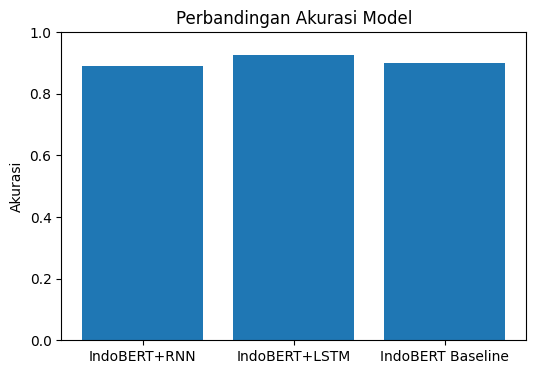

Akurasi RNN : 0.892
Akurasi LSTM: 0.926
Akurasi BERT: 0.9


In [ ]:
from sklearn.metrics import accuracy_score

acc_rnn = accuracy_score(true_rnn, pred_rnn)
acc_lstm = accuracy_score(true_lstm, pred_lstm)
acc_bert = accuracy_score(true_bert, pred_bert)

plt.figure(figsize=(6,4))
plt.bar(["IndoBERT+RNN", "IndoBERT+LSTM","IndoBERT Baseline"], [acc_rnn, acc_lstm,acc_bert])
plt.title("Perbandingan Akurasi Model")
plt.ylabel("Akurasi")
plt.ylim(0,1)
plt.show()

print("Akurasi RNN :", acc_rnn)
print("Akurasi LSTM:", acc_lstm)
print("Akurasi BERT:", acc_bert)